In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dotenv import find_dotenv, load_dotenv



In [ ]:
#load in the train data - explore and clean

#find the environment file
env_file = find_dotenv()
load_dotenv()

#path to train images
path = os.getenv("DR_IMAGES_PATH")
#path to csv file containing img id code and grading
label_csv = os.getenv("DR_LABELS_PATH")


if not os.path.isfile(label_csv):
    print(f"File not found")
else:
    pass


try:
    with open (label_csv, "r") as f:
     #our csv file
     df = pd.read_csv(f)
except Exception as e:
   raise FileNotFoundError("this file does not exist", e)   



image_code, label = df.iloc[0]["image"], df.iloc[0]["level"]




#print the first 5 labels
print(df.head())
#print the last 5 labels
print(df.tail())




      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
             image  level
35121  44347_right      0
35122   44348_left      0
35123  44348_right      0
35124   44349_left      0
35125  44349_right      1


100%|██████████| 35126/35126 [10:10<00:00, 57.53it/s]

(224, 224, 3)
56.16470689838435


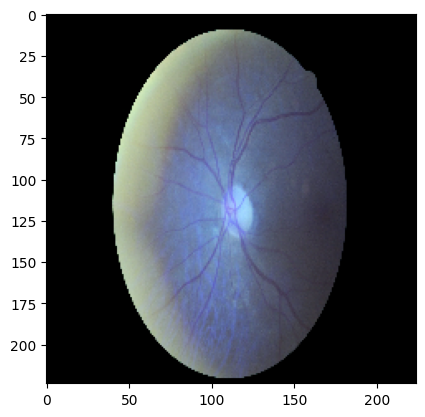

In [ ]:
#load in the train data - explore and clean
training_images=[]
corrupted_data=[]
#count the sample distribution per class 
count={"No DR" :0 , "Mild DR ": 0, "Moderate DR ": 0, "Severe DR ": 0, "Proliferative DR " : 0}
IMG_SIZE = 224
REBUILD = True




def inspect(path):
#iterate through the data in subsets, iterating through x images at a time
#for chunk in np.array_split(df, 1000):
    for idx ,i in tqdm(df.iterrows(), total=len(df)):
        try:
            img_path = os.path.join(path, f"{i['image']}.jpeg")
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
            label = df.iloc[idx]["level"]

            #ensure there are no corrupted files
            if img is None:
                print(f"error occured processing at row{df.iloc[idx]}")
                #skip the current iteration
                continue
                
            if pd.isna(label):
                #if any image within the csv file does not contain a label, we append the index of the the row, allowing us to later filter out
                corrupted_data.append(df.iloc[idx])

            #count the distribution of samples per class
            if label == 0:
                count["No DR"]+=1

            elif label == 1:
                count["Mild DR"]+=1

            elif label == 2:
                count["Moderate DR"]+=1

            elif label == 3:
                count["Severe DR"]+=1

            elif label == 4:
                count["Proliferative DR"]+=1                   


            #convert the labels to their to their label encoding format
            training_images.append([np.array(img), df.iloc[idx]["level"]])

        except Exception as e:
            print(f"error has occured at {i}")
            
       
    return training_images    


if REBUILD:
    train_data = inspect(path)

img, label = train_data[0][0], train_data[0][1]
print(img.shape)

#the mean value of pixels
print(np.mean(img))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()







    

In [43]:
#check to see if there are any images with missing labels
print(f"The number of msising labels found in the dataset are : {len(corrupted_data)}")
print(len(train_data))

The number of msising labels found in the dataset are : 0
35126


In [30]:
print(img.shape)
print(label)

(224, 224, 3)
0


Min pixel value: 0, Max pixel value: 255
35126


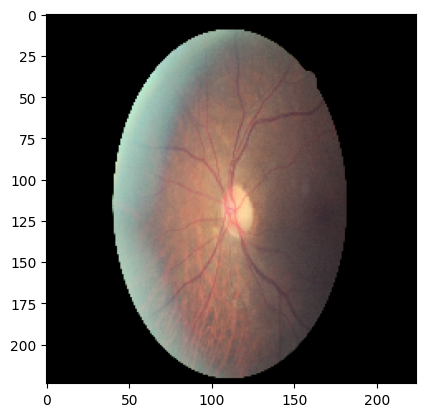

In [32]:
#print max and min pixel values of our image to see if normalized already or not
print(f"Min pixel value: {train_data[0][0].min()}, Max pixel value: {train_data[0][0].max()}")

#printing the length of our dataset
print(len(train_data))
#(3662, 224,224, 3), this represents the number of samples , and the shape of each image with 3 channels RGB

#visualize the first fundus image in the datset, ensure its in RGB
plt.imshow(cv2.cvtColor(train_data[0][0], cv2.COLOR_BGR2RGB))
plt.show()

4
DR label being shown is : 4


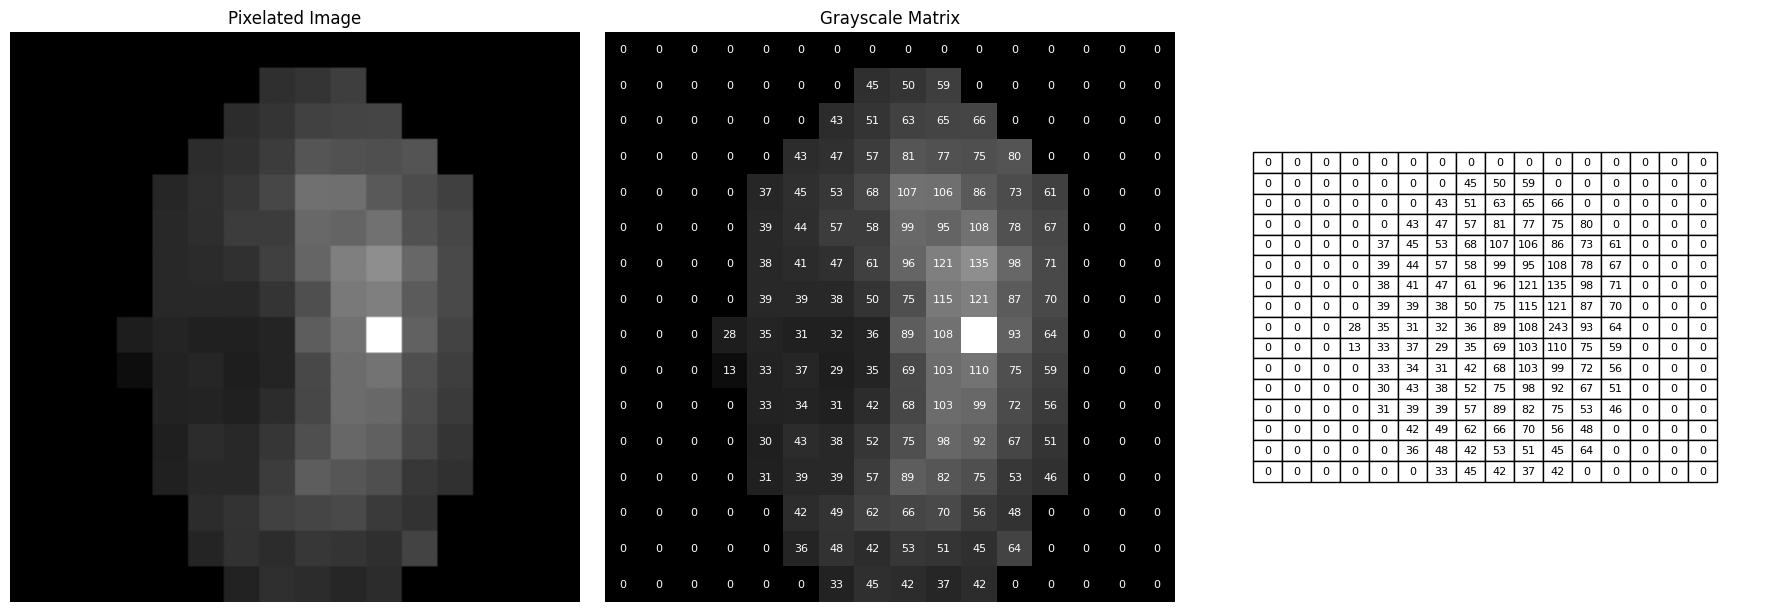

In [ ]:
# Display the pixel intensity values of a patient with Proliferative DR 
PDR_img = train_data[1613][0]  # Access the image of a patient with PDR (Proliferative DR)
print(f"DR label being shown is : {df.iloc[1613]["level"]}")

# Ensure the image is in grayscale
if len(PDR_img.shape) == 3:  # If the image has 3 channels (RGB/BGR)
    PDR_img = cv2.cvtColor(PDR_img, cv2.COLOR_BGR2GRAY)

# Resize the image to make it pixelated (16x16)
pixelated_image = cv2.resize(PDR_img, (16, 16), interpolation=cv2.INTER_NEAREST)

# Resize it back to the original size for visualization purposes
pixelated_resized = cv2.resize(pixelated_image, (PDR_img.shape[1], PDR_img.shape[0]), interpolation=cv2.INTER_NEAREST)

# Prepare the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Display the pixelated image resized back to the original size
axes[0].imshow(pixelated_resized, cmap='gray')
axes[0].set_title("Pixelated Image")
axes[0].axis('off')

# 2. Display the grayscale pixel values as an image
axes[1].imshow(pixelated_image, cmap='gray')
for i in range(pixelated_image.shape[0]):
    for j in range(pixelated_image.shape[1]):
        value = pixelated_image[i, j]
        # Display the pixel value on the image
        axes[1].text(j, i, f"{value}", color='white', ha='center', va='center', fontsize=8)
axes[1].set_title("Grayscale Matrix")
axes[1].axis('off')

# 3. Display the raw pixel values in a table format
axes[2].axis('tight')
axes[2].axis('off')
table_data = pixelated_image.astype(int)  # Ensure integer values for display
pixel_table = axes[2].table(
    cellText=table_data, loc='center', cellLoc='center', colWidths=[0.05] * 16
)
pixel_table.auto_set_font_size(False)
pixel_table.set_fontsize(8)

# Adjust layout for better visualization

plt.tight_layout()
plt.show()



# The pathology of Diabetic Retinopathy 
- Below is an Image of indicators we can notice in a DR patient

In [63]:
diagram_path = os.getenv("DIAGRAM_IMG")

# Display the image
display(Image(filename=diagram_path, width=600)) 


ValueError: No image data found. Expecting filename, url, or data.

# Raw Samples of Images before any Preprocessing
In this section we view the raw images of gradings without any preprocessing - note images were only just resized 

Appended image at index 0 for label 0
Appended image at index 1 for label 0
Appended image at index 4 for label 1
Appended image at index 5 for label 2
Appended image at index 6 for label 4
Appended image at index 7 for label 4
Appended image at index 9 for label 1
Appended image at index 23 for label 2
Appended image at index 90 for label 3
Appended image at index 91 for label 3


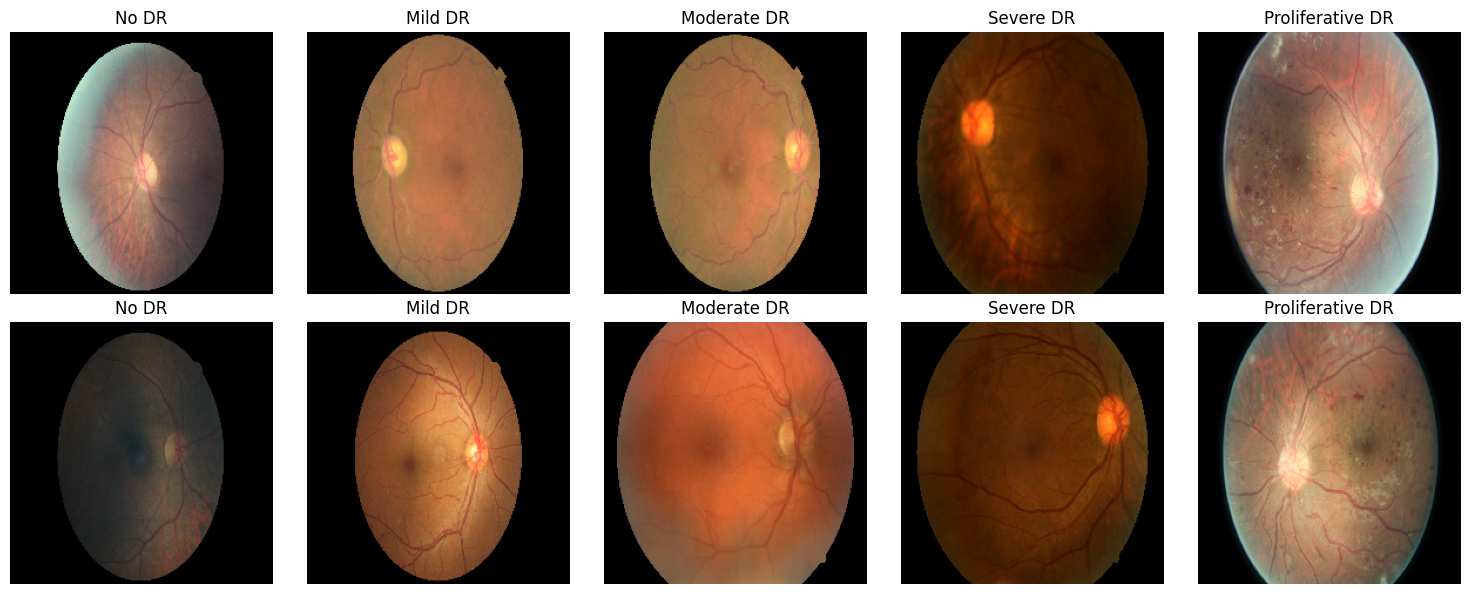

In [ ]:
#show some samples with their labels
#iterate through the samples
#if we get 2 samples of a single grading, then stop searching for that label

def fetch_samples(train_data, num_of_classes=5):
    sample_dict = {label: [] for label in range(num_of_classes)}
    
    for idx , data in enumerate(train_data):
         
        X, y  = data
        label = y
        

        #check if we already have the label in our dict
        if label not in sample_dict:
            sample_dict[label] = []
        
        if len(sample_dict[label])<2:
            sample_dict[label].append(X) 
            #confirmation to ensure we plot the exact images for each coressponding label
            print(f"Appended image at index {idx} for label {label}")
        #now if all samples have a list of 2, then exit the iteration
        # meaning {0:[img1,img5] etc}   

        #returns true if (sample) is true for all values in the iterable
        if all(len(sample)==2 for sample in sample_dict.values()):
            break

    return sample_dict    


data = fetch_samples(train_data)





#visualize 2 samples per grading with titles -  10 in total
def visualize_samples(samples):
    # Create a figure with 5 columns (for 5 labels) and 2 rows (for 2 images per label)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns

    # Iterate over the dictionary of samples
    for label, images in samples.items():
        for i, img in enumerate(images):
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Access the correct subplot using label and row index
            ax = axes[i, label]  # Row `i` and column `label`


            #change the value of lables to their correct severity gradings
            class_name= None

            if label == 0:
                class_name = "No DR"

            elif label == 1: 
                class_name = "Mild DR"    

            elif label == 2:
                class_name = "Moderate DR"  

            elif label == 3:
                class_name = "Severe DR"    

            elif label == 4:
                class_name = "Proliferative DR"      


            # Plot the image
            ax.imshow(img, cmap="gray")  # Use 'gray' or other colormaps as necessary
            ax.set_title(f"{class_name}")  # Set the title to show the class
            ax.axis("off")  # Turn off axes for cleaner visualization

    # Adjust layout
    plt.tight_layout()
    plt.show()


unprocessed_samples = visualize_samples(data)
unprocessed_samples



In [45]:
#number of samples per class
print(count)

{'No DR': 25810, 'Mild DR': 2443, 'Moderate DR': 5292, 'Severe DR': 873, 'Proliferative DR': 708}


# Class Distributions

A cruical part of data exploration is understanding the distributions of samples within the dataset.

- If the prevelence of the Majority class with respect to the Minority classes is high, then this leads to a biased model.

- A biased model will further affect generalizability as the model is not well trained on other DR gradings

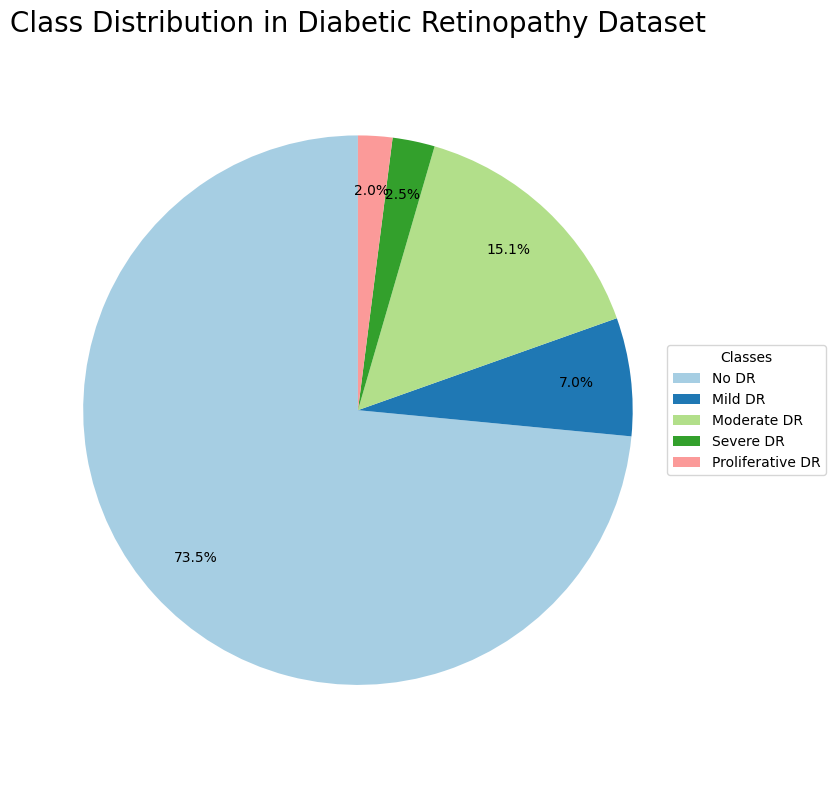

In [65]:
# Pie Chart

labels = count.keys()
sizes = count.values()

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sizes, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=plt.cm.Paired.colors, 
    pctdistance=0.8  # Adjust distance of the % labels from center
)

# Create a legend on the right side
plt.legend(wedges, labels, title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("Class Distribution in Diabetic Retinopathy Dataset", fontsize=20)
plt.axis('equal')  # Ensures pie is drawn as a circle
plt.tight_layout()
plt.show()


<BarContainer object of 5 artists>

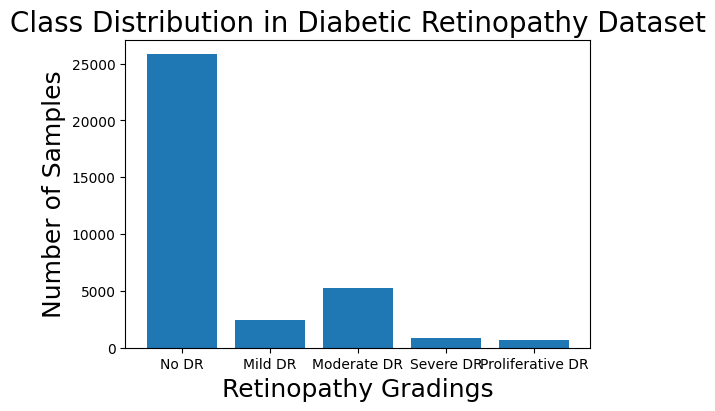

In [54]:
#visualising the class imbalance with a bar chart
plt.figure(figsize=(6, 4))  
plt.xlabel("Retinopathy Gradings", fontsize=18)
plt.ylabel("Number of Samples", fontsize=18)
plt.title("Class Distribution in Diabetic Retinopathy Dataset", fontsize=20)


plt.bar(count.keys(), count.values())
#plt.show()

# Splitting Train/Val/Test
- As we can see from the above Severity gradings, No DR has 25,810 samples which is exactly 73.5% of the total distribution.
- we will begin with splitting the data before any preprocessing into 70/15/15 split
- having a good amount of data for val and tests are crucial to understand how the model is performing
- with the usage of the val set we can fine tune hyperparameters whilst training and adjust any model architectures if we may



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

"""
we begin by splitting our dataset into a 70/15/15 split with stratified sampling, this ensure that our subsets all maintain the original distributions
from the original dataset. 
the Random seed ensures we always run the same splits

Assume x (inputs) and y (labels) are defined.
First, we split off the test set:
Then split the remaining data into training and validation sets:
 This results in roughly 80% training, 10% validation, and 10% test.
"""

RANDOM_SEED = 77
TEST_SIZE=0.5 # for the val/test split


image, label = df["image"], df["level"]
#shuffle our training data
X, y = shuffle(image, label, random_state=RANDOM_SEED)

#first lets split it 70/30 and use the 30% to split it into the val and test
train_x, x_temp, train_y , y_temp = train_test_split(X, y , test_size=0.3 ,random_state=RANDOM_SEED, stratify=y)
#now that we've splitted the train and test, we can split the val set from the X_train and y_train
val_x, test_x , val_y ,test_y = train_test_split(x_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp)

print(f"train set consists of {train_x.shape} samples")
print(train_y.shape)


print(f"val set consists of {val_x.shape} samples")
print(val_y.shape)

print(f"test set consists of {test_x.shape} samples")
print(test_y.shape)










train set consists of (24588,) samples
(24588,)
val set consists of (5269,) samples
(5269,)
test set consists of (5269,) samples
(5269,)
